# Learning Rate Experiments for Vanilla DQN

This notebook runs a learning-rate ablation study for the vanilla DQN LunarLander baseline. All baseline parameters are kept fixed except `learning_rate`.


## 1. Setup and Imports


In [1]:
import sys
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))

from core.vanilla_dqn_lunar_lander import (
    train_dqn,
    evaluate_dqn,
    save_plot,
    save_results,
    save_model,
)


Using device: cpu


## 2. Experiment Settings

Keep the vanilla baseline settings unchanged and vary only the learning rate.


In [2]:
learning_rates = [3e-3, 2e-3, 1e-3, 8e-4, 7e-4, 5e-4, 3e-4, 1e-4, 5e-5]
num_episodes = 500
num_eval_episodes = 10

base_hyperparameters = {
    'batch_size': 32,
    'update_frequency': 4,
    'target_update_frequency': 100,
    'num_layers': 2,
    'hidden_dim': 128,
    'epsilon_decay': 0.995,
    'gamma': 0.99,
    'num_episodes': num_episodes,
    'num_eval_episodes': num_eval_episodes,
}


## 3. Run Learning Rate Ablation

Each learning rate is trained, evaluated, and saved automatically under `results/ablations/learning_rate/<learning_rate>/`.


In [3]:
all_results = {}

print('=' * 70)
print('DQN Learning Rate Ablation Study')
print(f'Testing {len(learning_rates)} learning rates over {num_episodes} episodes each')
print('=' * 70)

for lr in learning_rates:
    variant_name = f'{lr:.0e}'

    print('' + '=' * 70)
    print(f'Training with learning_rate = {lr} ({variant_name})')
    print('=' * 70)

    agent, rewards, losses = train_dqn(
        num_episodes=num_episodes,
        batch_size=base_hyperparameters['batch_size'],
        update_frequency=base_hyperparameters['update_frequency'],
        target_update_frequency=base_hyperparameters['target_update_frequency'],
        num_layers=base_hyperparameters['num_layers'],
        hidden_dim=base_hyperparameters['hidden_dim'],
        epsilon_decay=base_hyperparameters['epsilon_decay'],
        learning_rate=lr,
    )

    print('Evaluating trained agent...')
    eval_rewards = evaluate_dqn(agent, num_episodes=num_eval_episodes)

    hyperparameters = dict(base_hyperparameters)
    hyperparameters['learning_rate'] = lr

    save_results(
        agent,
        rewards,
        losses,
        hyperparameters,
        experiment_name='learning_rate',
        variant_name=variant_name,
    )
    save_model(agent, experiment_name='learning_rate', variant_name=variant_name)
    save_plot(rewards, losses, experiment_name='learning_rate', variant_name=variant_name)

    final_avg_reward = float(np.mean(rewards[-25:]))
    eval_avg_reward = float(np.mean(eval_rewards))

    all_results[variant_name] = {
        'learning_rate': lr,
        'train_rewards': rewards,
        'losses': losses,
        'eval_rewards': eval_rewards,
        'final_avg_reward': final_avg_reward,
        'eval_avg_reward': eval_avg_reward,
        'best_reward': float(max(rewards)),
    }

    print(f'Finished {variant_name}: final train avg={final_avg_reward:.2f}, eval avg={eval_avg_reward:.2f}')

print('' + '=' * 70)
print('Learning rate ablation complete')
print('=' * 70)


DQN Learning Rate Ablation Study
Testing 9 learning rates over 500 episodes each
Training with learning_rate = 0.003 (3e-03)
State dimension: 8
Action dimension: 4
Episode 50/500 | Avg Reward (last 50): -162.03 | Epsilon: 0.778
Episode 100/500 | Avg Reward (last 50): -133.80 | Epsilon: 0.606
Episode 150/500 | Avg Reward (last 50): -125.66 | Epsilon: 0.471
Episode 200/500 | Avg Reward (last 50): -113.02 | Epsilon: 0.367
Episode 250/500 | Avg Reward (last 50): -130.19 | Epsilon: 0.286
Episode 300/500 | Avg Reward (last 50): -118.40 | Epsilon: 0.222
Episode 350/500 | Avg Reward (last 50): -109.09 | Epsilon: 0.173
Episode 400/500 | Avg Reward (last 50): -87.87 | Epsilon: 0.135
Episode 450/500 | Avg Reward (last 50): -61.03 | Epsilon: 0.105
Episode 500/500 | Avg Reward (last 50): -11.34 | Epsilon: 0.082
Evaluating trained agent...
Evaluation Episode 1: Reward = -237.30
Evaluation Episode 2: Reward = -132.84
Evaluation Episode 3: Reward = -214.94
Evaluation Episode 4: Reward = -254.10
Evalua

## 4. Compare Results


In [4]:
summary_rows = []

for variant_name, result in all_results.items():
    summary_rows.append({
        'variant': variant_name,
        'learning_rate': result['learning_rate'],
        'final_avg_reward_last_25': result['final_avg_reward'],
        'eval_avg_reward': result['eval_avg_reward'],
        'best_training_reward': result['best_reward'],
    })

summary_rows = sorted(summary_rows, key=lambda row: row['eval_avg_reward'], reverse=True)

print('Learning Rate Experiment Summary')
print('-' * 90)
print(f"{'Variant':<10} {'LR':<12} {'Final Avg (25)':<16} {'Eval Avg':<12} {'Best Train':<12}")
print('-' * 90)
for row in summary_rows:
    print(
        f"{row['variant']:<10} "
        f"{row['learning_rate']:<12.1e} "
        f"{row['final_avg_reward_last_25']:<16.2f} "
        f"{row['eval_avg_reward']:<12.2f} "
        f"{row['best_training_reward']:<12.2f}"
    )


Learning Rate Experiment Summary
------------------------------------------------------------------------------------------
Variant    LR           Final Avg (25)   Eval Avg     Best Train  
------------------------------------------------------------------------------------------
5e-04      5.0e-04      19.99            98.22        282.60      
2e-03      2.0e-03      -45.91           64.22        241.65      
1e-03      1.0e-03      -25.04           53.58        294.79      
1e-04      1.0e-04      16.47            40.43        299.72      
7e-04      7.0e-04      -18.37           25.96        274.04      
5e-05      5.0e-05      13.89            9.03         262.33      
8e-04      8.0e-04      -2.88            6.43         275.12      
3e-03      3.0e-03      18.92            -145.30      306.58      
3e-04      3.0e-04      -39.54           -179.05      295.49      


## 5. Plot Comparison


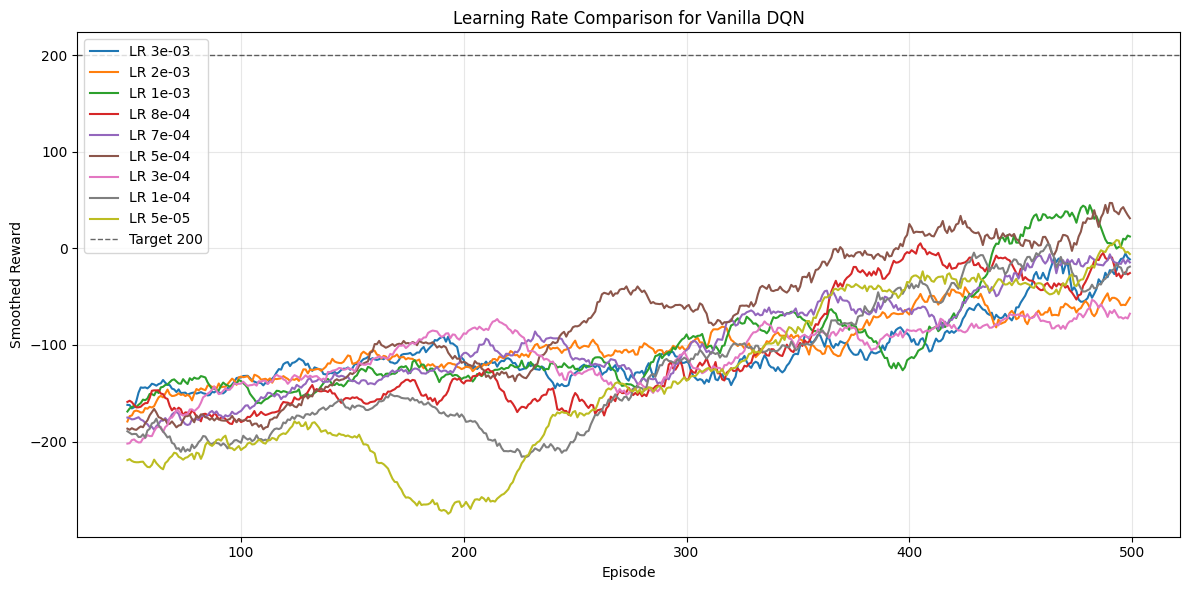

In [5]:
plt.figure(figsize=(12, 6))

for variant_name, result in all_results.items():
    rewards = result['train_rewards']
    window = min(50, max(1, len(rewards) // 2))
    if window > 1:
        smoothed = np.convolve(rewards, np.ones(window) / window, mode='valid')
        x_values = range(window - 1, window - 1 + len(smoothed))
        plt.plot(x_values, smoothed, label=f'LR {variant_name}')
    else:
        plt.plot(rewards, label=f'LR {variant_name}')

plt.axhline(y=200, color='black', linestyle='--', linewidth=1, alpha=0.6, label='Target 200')
plt.xlabel('Episode')
plt.ylabel('Smoothed Reward')
plt.title('Learning Rate Comparison for Vanilla DQN')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 6. Summary

This experiment tested nine learning rates for the vanilla DQN agent while keeping the other baseline settings fixed: 500 training episodes, batch size 32, two hidden layers, hidden dimension 128, epsilon decay 0.995, and gamma 0.99. The tested learning rates were `3e-3`, `2e-3`, `1e-3`, `8e-4`, `7e-4`, `5e-4`, `3e-4`, `1e-4`, and `5e-5`.

Overall, the results show that the learning rate has a clear effect on training stability and evaluation performance. Larger learning rates were not always better. The largest value, `3e-3`, reached a high best training reward (`306.58`), but its evaluation average was poor (`-145.30`), suggesting that the policy was unstable and did not generalize well during evaluation. The medium-to-high range around `1e-3` to `5e-4` performed better overall. In particular, `5e-4` achieved the best evaluation average (`98.22`) and a positive final training average over the last 25 episodes (`19.99`). Smaller learning rates such as `3e-4` and `5e-5` tended to learn more slowly or less consistently within 500 episodes.

| Learning Rate | Final Avg Reward (Last 25) | Evaluation Avg Reward | Best Training Reward |
|---:|---:|---:|---:|
| `5e-4` | `19.99` | `98.22` | `282.60` |
| `2e-3` | `-45.91` | `64.22` | `241.65` |
| `1e-3` | `-25.04` | `53.58` | `294.79` |
| `1e-4` | `16.47` | `40.43` | `299.72` |
| `7e-4` | `-18.37` | `25.96` | `274.04` |
| `5e-5` | `13.89` | `9.03` | `262.33` |
| `8e-4` | `-2.88` | `6.43` | `275.12` |
| `3e-3` | `18.92` | `-145.30` | `306.58` |
| `3e-4` | `-39.54` | `-179.05` | `295.49` |

Based on these results, `5e-4` is the best learning rate among the tested values. It produced the strongest evaluation performance and remained relatively stable near the end of training. Although some other learning rates achieved high individual training rewards, their evaluation averages were lower, which makes them less reliable choices for the final DQN configuration. Therefore, this experiment recommends `learning_rate = 5e-4` for the vanilla DQN setup.
